In [1]:
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf
from neuromodes.waves import simulate_waves, _simulate_waves_fem
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --------- SETUP ---------
nt = 100
seed = 0
surf, medmask = fetch_surf(density='4k')
solver = EigenSolver(surf, mask=medmask)
ext_input = np.random.default_rng(seed).standard_normal((solver.n_verts, nt))

In [3]:
print(solver.solve(solver.n_verts-1, seed=seed)) # solve n_verts-1 modes

EigenSolver
-----------
Surface mesh: 3636 vertices (366 others masked out), 7179 triangles
3635 eigenmodes computed


In [24]:
def correlate_models(dt):
    # FEM solution
    phi_fem = _simulate_waves_fem(solver.mass, solver.stiffness, ext_input=ext_input, dt=dt)

    # Modal approximations
    n_modes_all = [10, 50, 100, 200, 500, 1000, solver.n_modes]
    phi_modes = np.zeros((solver.n_verts, nt, len(n_modes_all)))
    for i, n_modes in enumerate(n_modes_all):
        # Run wave model with truncated emodes/evals
        phi_modes[:, :, i] = simulate_waves(
            solver.emodes[:, :n_modes],
            solver.evals[:n_modes],
            mass=solver.mass,
            ext_input=ext_input,
            dt=dt
            )
        
        # Correlate with FEM solution
        corrs = [np.corrcoef(phi_fem[:, t], phi_modes[:, t, i])[0, 1] for t in range(nt)]
        
        # Plot results
        plt.plot(corrs, label=n_modes)
    plt.legend(title='Modes', loc='lower right')
    plt.xlabel(f"Time step (dt={dt} s)")
    plt.ylabel("Correlation with FEM solution (r)")
    plt.xlim(0,nt-1)
    plt.ylim(0,1.02)
    plt.title("Accuracy of Modal Solutions to the Wave Equation")
    plt.show()

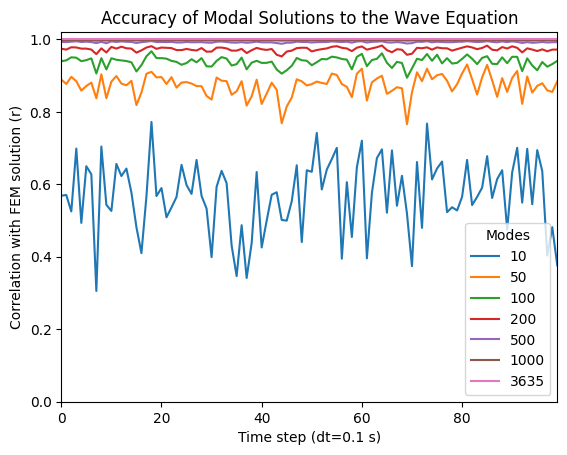

In [20]:
correlate_models(dt=1e-1)

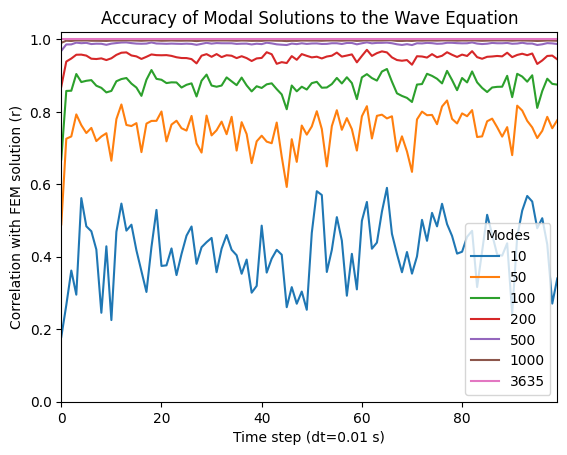

In [21]:
correlate_models(dt=1e-2)

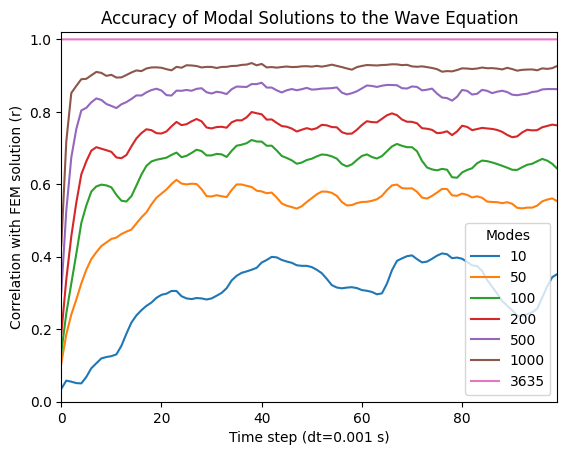

In [25]:
correlate_models(dt=1e-3)

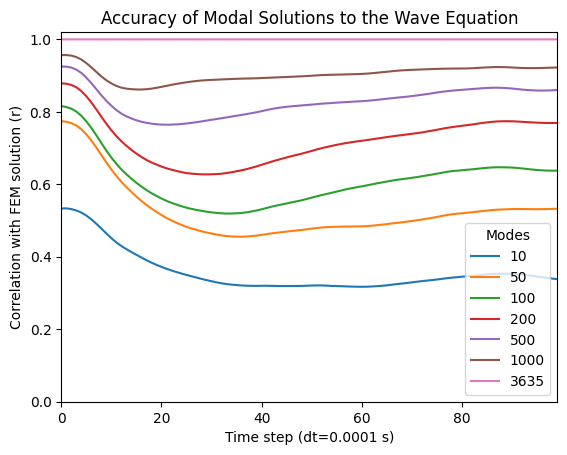

In [26]:
correlate_models(dt=1e-4)